<a href="https://colab.research.google.com/github/Soukthavilay/data-science-shoppee-thailand/blob/main/main_shopee_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# BÀI THI CUỐI KỲ — LẬP TRÌNH CHO KHOA HỌC DỮ LIỆU 2026

**Bộ dữ liệu:** Shopee TH Customer Journey & Operations Dataset (Kaggle)

**Bài toán:** Dự đoán trạng thái đơn hàng `item_status` (Completed / Cancelled / Refunded)

**Thuật toán:** Random Forest Classifier

---
| Phần | Nội dung | Điểm |
|------|----------|------|
| 1 | Đọc dữ liệu và chuẩn hóa | 2đ |
| 2 | Vẽ 2 biểu đồ thuộc tính dữ liệu | 2đ |
| 3 | Xây dựng & huấn luyện mô hình | 4đ |
| 4 | Hiển thị độ chính xác & hàm lỗi | 2đ |

## 0. Cài đặt thư viện & Tải dữ liệu

In [1]:
# Cài đặt thư viện cần thiết
!pip install kagglehub -q

In [2]:
# Import các thư viện
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings, time
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    log_loss, ConfusionMatrixDisplay, precision_recall_fscore_support
)

print('✅ Import thư viện thành công')

✅ Import thư viện thành công


In [3]:
# Tải dataset từ Kaggle
import kagglehub, os, glob

path = kagglehub.dataset_download(
    'hninshwezinhlaing/shopee-th-customer-journey-and-operations-dataset'
)
BASE = path
print('📁 Path to dataset:', path)

csv_files = glob.glob(os.path.join(path, '**', '*.csv'), recursive=True)
print(f'📂 Tìm thấy {len(csv_files)} file CSV:')
for f in csv_files:
    print(f'   {os.path.basename(f)}')

100%|██████████| 70.9M/70.9M [00:02<00:00, 28.6MB/s]

Extracting files...


📁 Path to dataset: /root/.cache/kagglehub/datasets/hninshwezinhlaing/shopee-th-customer-journey-and-operations-dataset/versions/1
📂 Tìm thấy 11 file CSV:
   shopee_website_sessions_thailand.csv
   shopee_products_thailand.csv
   shopee_session_activities_thailand.csv
   shopee_product_campaign_thailand.csv
   shopee_sellers_thailand.csv
   shopee_campaigns_thailand.csv
   shopee_customers_thailand.csv
   shopee_reviews_thailand.csv
   shopee_order_items_thailand.csv
   shopee_orders_thailand.csv
   shopee_shipments_thailand.csv


## 1. Đọc dữ liệu và chuẩn hóa dữ liệu

In [4]:
# ── 1.1 Đọc dữ liệu ─────────────────────────────────────────
order_items = pd.read_csv(f'{BASE}/shopee_order_items_thailand.csv')
products    = pd.read_csv(f'{BASE}/shopee_products_thailand.csv')

print(f'📋 order_items : {order_items.shape[0]:,} dòng x {order_items.shape[1]} cột')
print(f'📋 products    : {products.shape[0]:,} dòng x {products.shape[1]} cột')
print('\n── Kiểu dữ liệu order_items ──')
print(order_items.dtypes.to_string())
print('\n── 3 dòng đầu ──')
order_items.head(3)

📋 order_items : 480,481 dòng x 16 cột
📋 products    : 4,880 dòng x 8 cột

── Kiểu dữ liệu order_items ──
order_item_id                  int64
order_id                       int64
product_id                    object
quantity                       int64
unit_price                   float64
unit_price_after_discount    float64
line_total                   float64
discount_percent             float64
commission_amount            float64
maintenance_amount           float64
shipping_fee_item            float64
estimated_delivery_start      object
estimated_delivery_end        object
item_status                   object
is_campaign                    int64
product_campaign_id           object

── 3 dòng đầu ──


,order_item_id,order_id,product_id,quantity,unit_price,unit_price_after_discount,line_total,discount_percent,commission_amount,maintenance_amount,shipping_fee_item,estimated_delivery_start,estimated_delivery_end,item_status,is_campaign,product_campaign_id
0,1,1,P002264,1,6823.94,6025.54,6025.54,11.7,482.04,0.0,200.0,2025-12-12,2025-12-14 00:00:00,Completed,1,NaN
1,2,2,P003102,1,7955.43,7955.43,7955.43,0.0,636.43,0.0,150.0,2023-04-06,2023-04-08 00:00:00,Cancelled,0,NaN
2,3,3,P002758,1,34.34,34.34,34.34,0.0,1.03,0.0,50.0,2024-09-21,2024-09-23 00:00:00,Completed,0,NaN


In [5]:
# ── 1.2 Thống kê mô tả ──────────────────────────────────────
print('── Thống kê mô tả (order_items) ──')
order_items[['unit_price', 'unit_price_after_discount',
             'discount_percent', 'shipping_fee_item',
             'commission_amount', 'quantity']].describe().round(2)

── Thống kê mô tả (order_items) ──


,unit_price,unit_price_after_discount,discount_percent,shipping_fee_item,commission_amount,quantity
count,480481.00,480481.00,480481.00,480481.00,480481.00,480481.00
mean,6084.15,6035.55,0.89,105.61,596.24,1.40
std,6485.73,6441.84,3.09,63.99,697.52,0.73
min,20.00,18.55,0.00,20.00,0.56,1.00
25%,542.09,535.07,0.00,50.00,59.10,1.00
50%,4760.23,4712.89,0.00,100.00,427.41,1.00
75%,9368.59,9297.16,0.00,150.00,860.52,2.00
max,44999.85,44999.85,25.00,200.00,8965.82,4.00


In [6]:
# ── 1.3 Kiểm tra giá trị thiếu (Missing Values) ─────────────
print('── Missing Values — order_items ──')
missing = order_items.isnull().sum()
mv = missing[missing > 0]
if len(mv):
    pct = (mv / len(order_items) * 100).round(2)
    print(pd.DataFrame({'missing_count': mv, 'missing_%': pct}).to_string())
else:
    print('  ✅ Không có missing values')

print('\n── Missing Values — products ──')
mv_p = products.isnull().sum()
mv_p = mv_p[mv_p > 0]
print(mv_p.to_string() if len(mv_p) else '  ✅ Không có missing values')

── Missing Values — order_items ──
                     missing_count  missing_%
product_campaign_id         470134      97.85

── Missing Values — products ──
  ✅ Không có missing values


In [7]:
# ── 1.4 Phân phối nhãn mục tiêu ─────────────────────────────
print('── Phân phối nhãn: item_status ──')
label_dist = order_items['item_status'].value_counts()
label_pct  = order_items['item_status'].value_counts(normalize=True).mul(100).round(2)
print(pd.DataFrame({'count': label_dist, '%': label_pct}).to_string())

── Phân phối nhãn: item_status ──
              count      %
item_status               
Completed    360187  74.96
Cancelled     96229  20.03
Refunded      24065   5.01


In [8]:
# ── 1.5 Merge dữ liệu ───────────────────────────────────────
# Kết hợp order_items với products để lấy thêm category, commission_rate, maintenance_rate
df = order_items.merge(
    products[['product_id', 'category', 'commission_rate', 'maintenance_rate']],
    on='product_id', how='left'
)
print(f'Sau merge: {df.shape[0]:,} dòng x {df.shape[1]} cột')
df.head(3)

Sau merge: 480,481 dòng x 19 cột


,order_item_id,order_id,product_id,quantity,unit_price,unit_price_after_discount,line_total,discount_percent,commission_amount,maintenance_amount,shipping_fee_item,estimated_delivery_start,estimated_delivery_end,item_status,is_campaign,product_campaign_id,category,commission_rate,maintenance_rate
0,1,1,P002264,1,6823.94,6025.54,6025.54,11.7,482.04,0.0,200.0,2025-12-12,2025-12-14 00:00:00,Completed,1,NaN,Home,0.08,0.0
1,2,2,P003102,1,7955.43,7955.43,7955.43,0.0,636.43,0.0,150.0,2023-04-06,2023-04-08 00:00:00,Cancelled,0,NaN,Home,0.08,0.0
2,3,3,P002758,1,34.34,34.34,34.34,0.0,1.03,0.0,50.0,2024-09-21,2024-09-23 00:00:00,Completed,0,NaN,Groceries,0.03,0.0


In [9]:
# ── 1.6 Label Encoding cho biến categorical ─────────────────
le_cat    = LabelEncoder()
le_target = LabelEncoder()

df['category_enc'] = le_cat.fit_transform(df['category'])
df['label']        = le_target.fit_transform(df['item_status'])

print('── Encoding: category ──')
for i, cls in enumerate(le_cat.classes_):
    print(f'   {cls} → {i}')

print('\n── Encoding: item_status (target) ──')
for i, cls in enumerate(le_target.classes_):
    print(f'   {cls} → {i}')

── Encoding: category ──
   Beauty → 0
   Electronics → 1
   Fashion → 2
   Groceries → 3
   Home → 4

── Encoding: item_status (target) ──
   Cancelled → 0
   Completed → 1
   Refunded → 2


In [10]:
# ── 1.7 Chuẩn hóa dữ liệu (StandardScaler — Z-score) ────────
# Công thức: x' = (x - μ) / σ  →  mean ≈ 0, std ≈ 1

NUMERIC_COLS = [
    'quantity', 'unit_price', 'unit_price_after_discount',
    'discount_percent', 'commission_amount', 'maintenance_amount',
    'shipping_fee_item', 'is_campaign', 'commission_rate',
    'maintenance_rate',
]
ALL_FEATURES = NUMERIC_COLS + ['category_enc']

scaler = StandardScaler()
X = scaler.fit_transform(df[ALL_FEATURES])
y = df['label'].values

print('── Sau chuẩn hóa StandardScaler ──')
print(f'   Shape X : {X.shape}')
print(f'   mean X  : {X.mean(axis=0).round(3)}')
print(f'   std  X  : {X.std(axis=0).round(3)}')

# ── 1.8 Chia tập train / test (80/20, stratify) ─────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'\n── Chia dữ liệu (80/20) ──')
print(f'   Train : {X_train.shape[0]:,} mẫu')
print(f'   Test  : {X_test.shape[0]:,} mẫu')
print('\n✅ Hoàn thành Phần 1 — Đọc & Chuẩn hóa dữ liệu')

── Sau chuẩn hóa StandardScaler ──
   Shape X : (480481, 11)
   mean X  : [-0.  0. -0. -0. -0. -0. -0.  0. -0.  0. -0.]
   std  X  : [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]

── Chia dữ liệu (80/20) ──
   Train : 384,384 mẫu
   Test  : 96,097 mẫu

✅ Hoàn thành Phần 1 — Đọc & Chuẩn hóa dữ liệu


## 2. Vẽ 2 biểu đồ thuộc tính dữ liệu

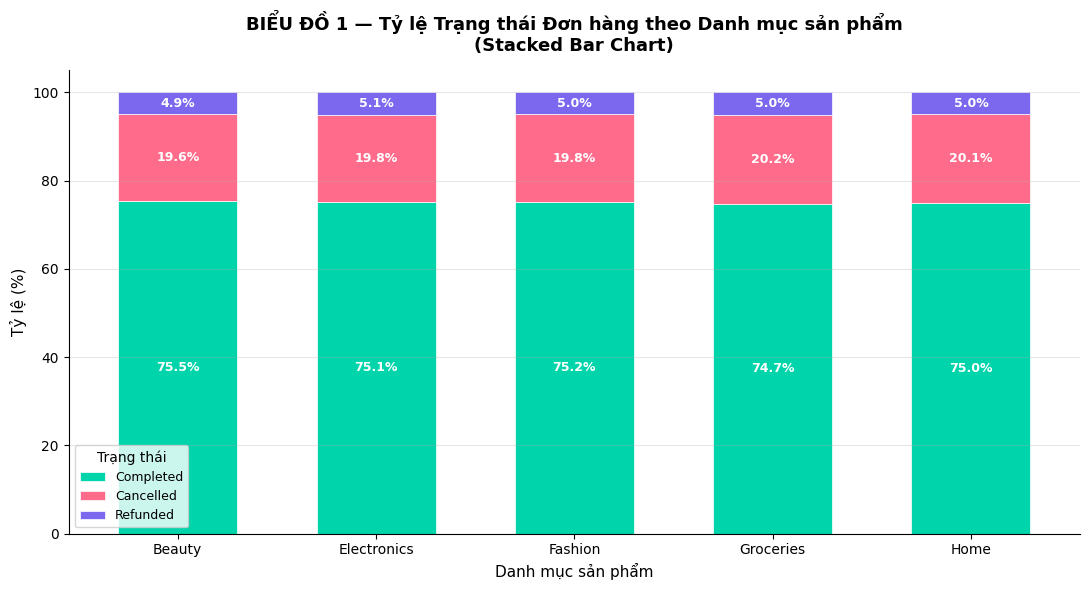

✅ Đã lưu: bieu_do_1_stacked_bar.png


In [11]:
# ── BIỂU ĐỒ 1: Stacked Bar — Tỷ lệ item_status theo Category ─
PALETTE = {'Completed': '#00d4aa', 'Cancelled': '#ff6b8a', 'Refunded': '#7b68ee'}

fig1, ax1 = plt.subplots(figsize=(11, 6))

pivot = df.groupby(['category', 'item_status']).size().unstack(fill_value=0)
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100
status_order = ['Completed', 'Cancelled', 'Refunded']
pivot_pct[status_order].plot(
    kind='bar', stacked=True, ax=ax1,
    color=[PALETTE[s] for s in status_order],
    edgecolor='white', linewidth=0.5, width=0.6
)
for container in ax1.containers:
    ax1.bar_label(container, fmt='%.1f%%', label_type='center',
                  fontsize=9, color='white', fontweight='bold')

ax1.set_title('BIỂU ĐỒ 1 — Tỷ lệ Trạng thái Đơn hàng theo Danh mục sản phẩm\n(Stacked Bar Chart)',
              fontsize=13, fontweight='bold', pad=14)
ax1.set_xlabel('Danh mục sản phẩm', fontsize=11)
ax1.set_ylabel('Tỷ lệ (%)', fontsize=11)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=0, fontsize=10)
ax1.legend(title='Trạng thái', framealpha=0.8, fontsize=9)
ax1.grid(True, axis='y', alpha=0.3)
sns.despine()
plt.tight_layout()
plt.savefig('bieu_do_1_stacked_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Đã lưu: bieu_do_1_stacked_bar.png')

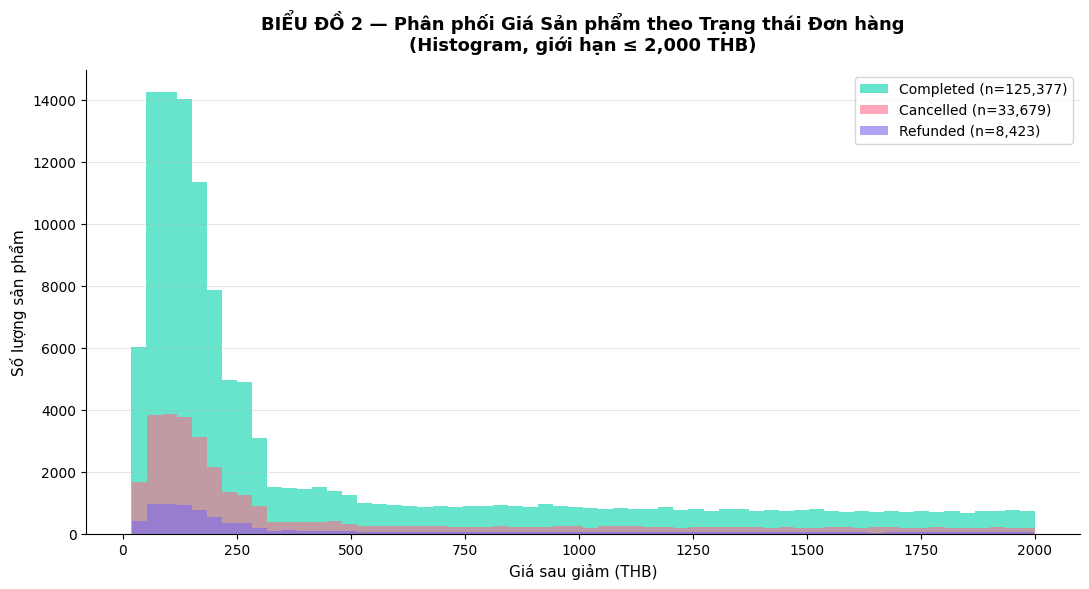

✅ Đã lưu: bieu_do_2_histogram.png

✅ Hoàn thành Phần 2 — Vẽ 2 biểu đồ


In [12]:
# ── BIỂU ĐỒ 2: Histogram — Phân phối Giá theo item_status ───
fig2, ax2 = plt.subplots(figsize=(11, 6))

PRICE_CAP = 2000
for status, color in PALETTE.items():
    data_plot = df[df['item_status'] == status]['unit_price_after_discount']
    data_plot = data_plot[data_plot <= PRICE_CAP]
    ax2.hist(data_plot, bins=60, color=color, alpha=0.6,
             label=f'{status} (n={len(data_plot):,})', edgecolor='none')

ax2.set_title('BIỂU ĐỒ 2 — Phân phối Giá Sản phẩm theo Trạng thái Đơn hàng\n(Histogram, giới hạn ≤ 2,000 THB)',
              fontsize=13, fontweight='bold', pad=14)
ax2.set_xlabel('Giá sau giảm (THB)', fontsize=11)
ax2.set_ylabel('Số lượng sản phẩm', fontsize=11)
ax2.legend(fontsize=10)
ax2.grid(True, axis='y', alpha=0.3)
sns.despine()
plt.tight_layout()
plt.savefig('bieu_do_2_histogram.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Đã lưu: bieu_do_2_histogram.png')
print('\n✅ Hoàn thành Phần 2 — Vẽ 2 biểu đồ')

## 3. Xây dựng và huấn luyện mô hình Random Forest

In [13]:
# ── 3.1 Định nghĩa siêu tham số ─────────────────────────────
# Random Forest: tập hợp nhiều cây quyết định (Decision Tree)
# Mỗi cây học trên tập con ngẫu nhiên → giảm overfitting
# Kết quả dự đoán = bỏ phiếu đa số giữa tất cả các cây

params = dict(
    n_estimators      = 200,   # số cây trong rừng
    max_depth         = 10,    # độ sâu tối đa mỗi cây
    min_samples_split = 5,     # số mẫu tối thiểu để tách nút
    random_state      = 42,    # cố định kết quả
    n_jobs            = -1,    # dùng tất cả CPU core
)

print('── Siêu tham số (Hyperparameters) ──')
for k, v in params.items():
    print(f'   {k:<22}: {v}')

── Siêu tham số (Hyperparameters) ──
   n_estimators          : 200
   max_depth             : 10
   min_samples_split     : 5
   random_state          : 42
   n_jobs                : -1


In [14]:
# ── 3.2 Huấn luyện mô hình ──────────────────────────────────
model = RandomForestClassifier(**params)

print(f'⏳ Đang huấn luyện trên {X_train.shape[0]:,} mẫu...')
t0 = time.time()
model.fit(X_train, y_train)
elapsed = time.time() - t0
print(f'✅ Huấn luyện xong! ({elapsed:.1f} giây)')

⏳ Đang huấn luyện trên 384,384 mẫu...
✅ Huấn luyện xong! (146.2 giây)


── Mức độ quan trọng các đặc trưng (Feature Importance) ──
   unit_price                  : 0.2431  ██████████████
   unit_price_after_discount   : 0.2378  ██████████████
   commission_amount           : 0.2225  █████████████
   maintenance_amount          : 0.1219  ███████
   discount_percent            : 0.0857  █████
   shipping_fee_item           : 0.0261  █
   quantity                    : 0.0258  █
   maintenance_rate            : 0.0135  
   is_campaign                 : 0.0100  
   category_enc                : 0.0077  
   commission_rate             : 0.0059  


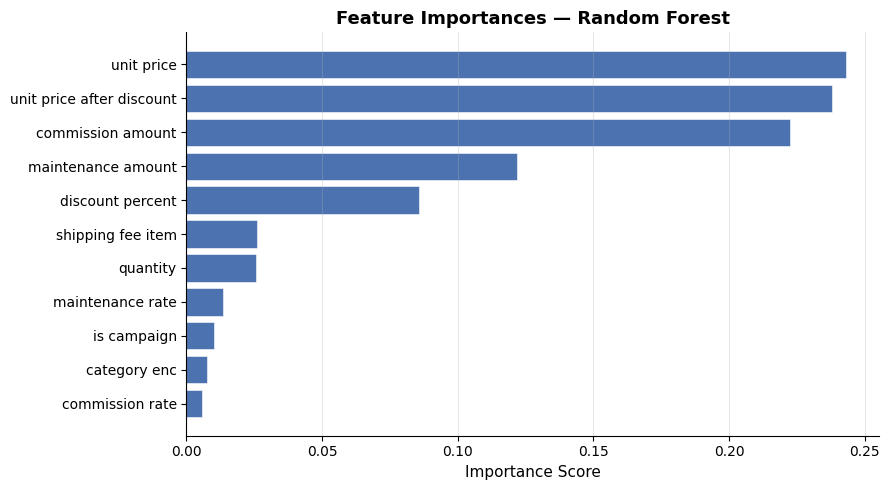


✅ Hoàn thành Phần 3 — Xây dựng & Huấn luyện mô hình


In [15]:
# ── 3.3 Feature Importance ──────────────────────────────────
importances  = model.feature_importances_
feature_names = ALL_FEATURES

print('── Mức độ quan trọng các đặc trưng (Feature Importance) ──')
for score, name in sorted(zip(importances, feature_names), reverse=True):
    bar = '█' * int(score * 60)
    print(f'   {name:<28}: {score:.4f}  {bar}')

# Vẽ biểu đồ Feature Importance
sorted_idx = np.argsort(importances)
plt.figure(figsize=(9, 5))
plt.barh(
    [feature_names[i].replace('_', ' ') for i in sorted_idx],
    importances[sorted_idx],
    color='#4C72B0', edgecolor='white', linewidth=0.4
)
plt.xlabel('Importance Score', fontsize=11)
plt.title('Feature Importances — Random Forest', fontsize=13, fontweight='bold')
plt.grid(True, axis='x', alpha=0.3)
sns.despine()
plt.tight_layout()
plt.show()
print('\n✅ Hoàn thành Phần 3 — Xây dựng & Huấn luyện mô hình')

## 4. Hiển thị độ chính xác và hàm lỗi của mô hình

In [16]:
# ── 4.1 Dự đoán trên tập test ───────────────────────────────
y_pred       = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)

# ── 4.2 Tính các chỉ số đánh giá ────────────────────────────
acc  = accuracy_score(y_test, y_pred)
loss = log_loss(y_test, y_pred_proba)
cm   = confusion_matrix(y_test, y_pred)
cr   = classification_report(y_test, y_pred, target_names=le_target.classes_)

# ── 4.3 Hiển thị kết quả (TEXT) ─────────────────────────────
print('=' * 60)
print(f'  ✅ Accuracy (Độ chính xác) : {acc * 100:.2f}%')
print(f'  📉 Log Loss (Hàm lỗi)     : {loss:.6f}')
print('=' * 60)

print('\n── Confusion Matrix (Hàng = thực tế, Cột = dự đoán) ──')
cm_df = pd.DataFrame(
    cm,
    index  =[f'Thực: {c}'    for c in le_target.classes_],
    columns=[f'Dự đoán: {c}' for c in le_target.classes_]
)
print(cm_df.to_string())

print('\n── Classification Report ──')
print(cr)

print(f'Giải thích Log Loss = {loss:.4f}')
print('→ Log Loss càng gần 0 → mô hình dự đoán xác suất càng chính xác.')

  ✅ Accuracy (Độ chính xác) : 74.96%
  📉 Log Loss (Hàm lỗi)     : 0.688127

── Confusion Matrix (Hàng = thực tế, Cột = dự đoán) ──
                 Dự đoán: Cancelled  Dự đoán: Completed  Dự đoán: Refunded
Thực: Cancelled                   0               19246                  0
Thực: Completed                   0               72038                  0
Thực: Refunded                    0                4813                  0

── Classification Report ──
              precision    recall  f1-score   support

   Cancelled       0.00      0.00      0.00     19246
   Completed       0.75      1.00      0.86     72038
    Refunded       0.00      0.00      0.00      4813

    accuracy                           0.75     96097
   macro avg       0.25      0.33      0.29     96097
weighted avg       0.56      0.75      0.64     96097

Giải thích Log Loss = 0.6881
→ Log Loss càng gần 0 → mô hình dự đoán xác suất càng chính xác.


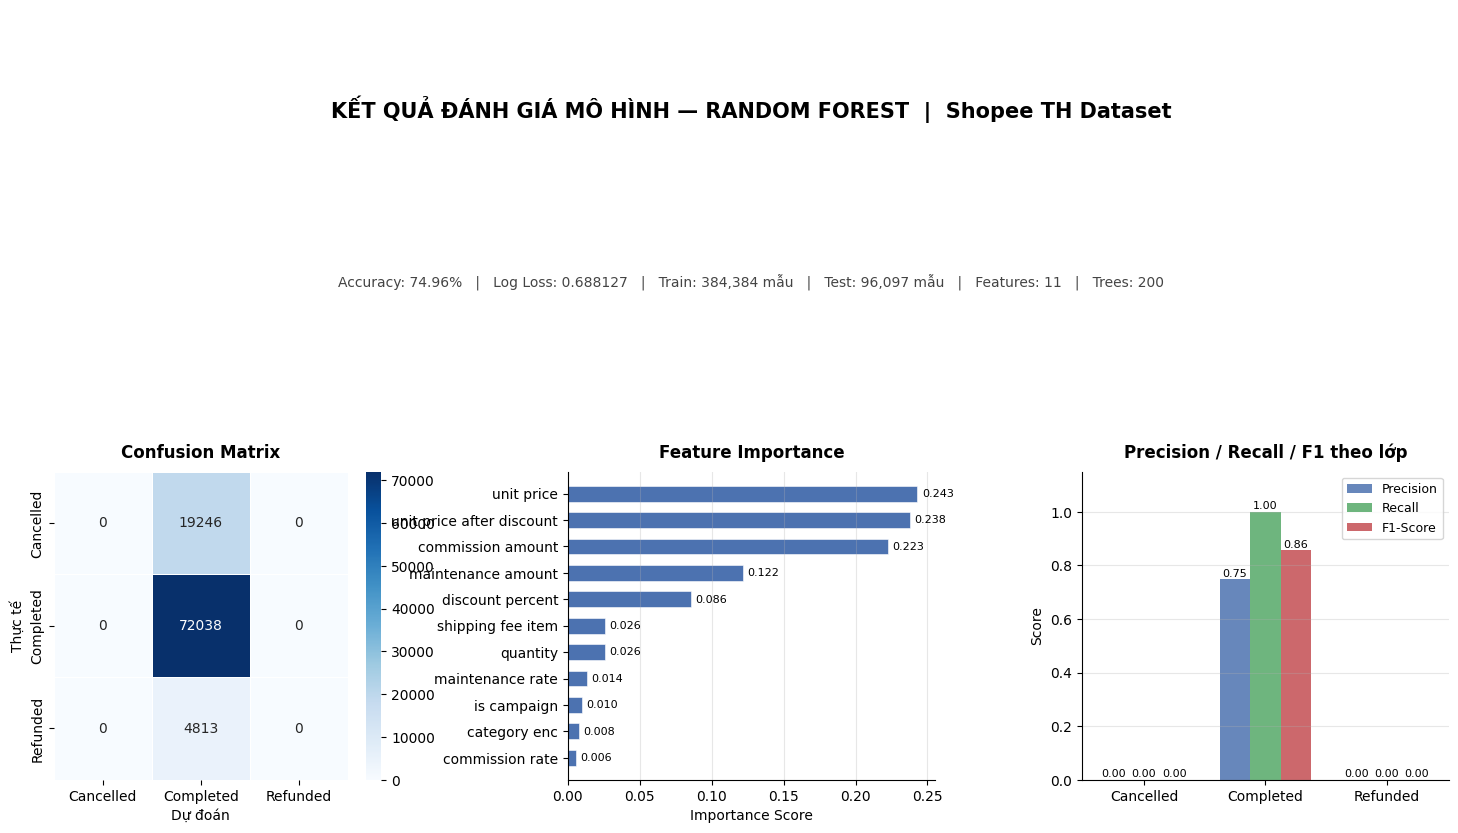

✅ Đã lưu: phan_4_ket_qua_mo_hinh.png

✅ Hoàn thành Phần 4 — Đánh giá mô hình


In [17]:
# ── 4.4 Hiển thị kết quả (HÌNH ẢNH) ────────────────────────
PALETTE3 = ['#4C72B0', '#55A868', '#C44E52']

fig = plt.figure(figsize=(18, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.50, wspace=0.40)

# Header
ax_h = fig.add_subplot(gs[0, :])
ax_h.axis('off')
ax_h.text(0.5, 0.65,
    'KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH — RANDOM FOREST  |  Shopee TH Dataset',
    ha='center', fontsize=15, fontweight='bold')
ax_h.text(0.5, 0.1,
    f'Accuracy: {acc*100:.2f}%   |   Log Loss: {loss:.6f}   |   '
    f'Train: {X_train.shape[0]:,} mẫu   |   Test: {X_test.shape[0]:,} mẫu   |   '
    f'Features: {X.shape[1]}   |   Trees: 200',
    ha='center', fontsize=10, color='#444444')

# Subplot 1: Confusion Matrix
ax1 = fig.add_subplot(gs[1, 0])
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=le_target.classes_,
    yticklabels=le_target.classes_,
    ax=ax1, linewidths=0.5, linecolor='white'
)
ax1.set_title('Confusion Matrix', fontsize=12, fontweight='bold', pad=10)
ax1.set_xlabel('Dự đoán', fontsize=10)
ax1.set_ylabel('Thực tế', fontsize=10)

# Subplot 2: Feature Importance
ax2 = fig.add_subplot(gs[1, 1])
sorted_idx  = np.argsort(importances)
feat_labels = [feature_names[i].replace('_', ' ') for i in sorted_idx]
bars = ax2.barh(feat_labels, importances[sorted_idx],
                color='#4C72B0', edgecolor='white', linewidth=0.4, height=0.6)
for bar, val in zip(bars, importances[sorted_idx]):
    ax2.text(val + 0.003, bar.get_y() + bar.get_height() / 2,
             f'{val:.3f}', va='center', fontsize=8)
ax2.set_title('Feature Importance', fontsize=12, fontweight='bold', pad=10)
ax2.set_xlabel('Importance Score')
ax2.grid(True, axis='x', alpha=0.3)
sns.despine(ax=ax2)

# Subplot 3: Precision / Recall / F1
ax3 = fig.add_subplot(gs[1, 2])
prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred, labels=[0, 1, 2])
classes = list(le_target.classes_)
x, w = np.arange(len(classes)), 0.25
ax3.bar(x - w, prec, w, label='Precision', color=PALETTE3[0], alpha=0.85)
ax3.bar(x,     rec,  w, label='Recall',    color=PALETTE3[1], alpha=0.85)
ax3.bar(x + w, f1,   w, label='F1-Score',  color=PALETTE3[2], alpha=0.85)
for i, (p, r, f) in enumerate(zip(prec, rec, f1)):
    ax3.text(i - w, p + 0.01, f'{p:.2f}', ha='center', fontsize=8)
    ax3.text(i,     r + 0.01, f'{r:.2f}', ha='center', fontsize=8)
    ax3.text(i + w, f + 0.01, f'{f:.2f}', ha='center', fontsize=8)
ax3.set_xticks(x)
ax3.set_xticklabels(classes, fontsize=10)
ax3.set_ylim(0, 1.15)
ax3.set_title('Precision / Recall / F1 theo lớp', fontsize=12, fontweight='bold', pad=10)
ax3.set_ylabel('Score')
ax3.legend(fontsize=9)
ax3.grid(True, axis='y', alpha=0.3)
sns.despine(ax=ax3)

plt.savefig('phan_4_ket_qua_mo_hinh.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Đã lưu: phan_4_ket_qua_mo_hinh.png')
print('\n✅ Hoàn thành Phần 4 — Đánh giá mô hình')

---
## ✅ Tổng kết

| Phần | Nội dung | Kết quả |
|------|----------|---------|
| 1 | Đọc & Chuẩn hóa dữ liệu | 480,481 mẫu, StandardScaler |
| 2 | Biểu đồ 1: Stacked Bar theo Category | ✅ |
| 2 | Biểu đồ 2: Histogram Giá theo Status | ✅ |
| 3 | Random Forest (200 cây, max_depth=10) | ✅ |
| 4 | Accuracy, Log Loss, Confusion Matrix, F1 | ✅ |